In [1]:
class DataOverviewer:
    def __init__(self):
     pass 
    def datasetOverview(self,df):
        print (" \033[1mDataset Overview\033[0m:\n")
        print(df.head(10))
        print("Number of rows and columns of dataset are :", df.shape)
        df.info()
        

In [2]:
class AMLExplorer:
    def __init__(self, df, label_col = "Is_laundering"):
        self.df = df.copy()
        self.label_col = label_col
        
    def plot_class_distribution(self):
        tr_probs = self.df[self.label_col].value_counts(normalize = True)
        print(tr_probs)
        plt.figure(figsize=(6,4))
        tr_bars = plt.bar(tr_probs.index.astype(str), tr_probs.values)
        
        for i , bar in enumerate(tr_bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height*100:.1f}%",ha='center',va='bottom'
            )
        
        plt.xlabel("Transaction Class")
        plt.ylabel("Probability")
        plt.ylim(0,max(tr_probs.values) * 1.05)
        plt.title("Empirical Probability of Transaction Classes")
        plt.tight_layout()
        plt.show()
         
 
    def eda_amount(self,amount_col = "Amount"):
        print(self.df[amount_col].isna().mean())
        print(self.df[amount_col].describe())

        print(self.df[amount_col].describe(percentiles = [0.5 , 0.9 , 0.95, 0.99 ,0.999]))

        sns.histplot(self.df[amount_col],bins = 100)
        plt.title("Raw Amount Distribution")
        plt.show()

        #Visualize again to see a sensible shape 
        self.df["Log_amount"] = np.log1p(self.df["Amount"])
        sns.histplot(self.df["Log_amount"],bins = 100)
        plt.title("Log-Transformed Amount Distribution")
        plt.show()

        #Comparison between the distribution of fraud and normal and see any meaning of Amount
        #Use a sample for plotting because of the million rows/transactions

        df_sample = self.df.sample(100_000,random_state = 42)
        sns.boxplot(
            x = "Is_laundering",
            y = "Log_amount",
            data = df_sample)

        plt.title("Log Amount vs Transaction Class (Boxplot)")
        plt.show()
       
        return self.df

In [3]:
import pandas as pd
class DataFrame_Split:
    def __init__(self):
        pass
    #Pick a cut point with the quantile to separate the train_df from the test one
    def train_test_split(self,df):
        df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])
        df = df.sort_values("timestamp")
        split_time = df["timestamp"].quantile(0.8)
        train_df = df[df["timestamp"] <= split_time].copy()
        test_df = df[df["timestamp"] > split_time].copy()            
        return train_df,test_df

In [4]:
import numpy as np
class BasicFeatureEngineering:
    def __init__(self):
        pass
    def new_features(self,train_df,test_df):
        for df in [train_df,test_df]:
            df["Log_Amount"] = np.log1p(df["Amount"])
            df["hour"] = df["timestamp"].dt.hour
            df["day_of_week"] = df["timestamp"].dt.weekday
            df["weekend"] = df["day_of_week"].isin([5,6]).astype(int)
        return train_df, test_df
    def fit_risky_flags(self, train_df, col):
        #Copy the traindf to have different "instances" of our data from the start until the end
        train_df = train_df.copy()
        risky_pairs = set()
        #Overall fraud calculation for the comparison with the risky combinations
        overall_fraud = train_df["Is_laundering"].mean()
        #Making zone values in which under each zone falls amount values
        bin_edges = train_df["Amount"].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
        bin_edges = np.unique(bin_edges)

        train_df["Amount_decile"] = pd.cut(
                train_df["Amount"],
                bins = bin_edges,
                include_lowest = True,
                labels = False,
                duplicates = "drop"
        )

        for dec in train_df["Amount_decile"].dropna().unique():
            subset = train_df[train_df["Amount_decile"] == dec]
            #With groupby()[].mean(). It's like calculating the conditional probability
            #How much risky/fraud is when having for example the hour column for a certain dec because
            #of the reducing dataframe where we examine the groupby combinations ec hour 2 mean 0.05 , hour3 mean 0.3
            
            comb_df = subset.groupby(col)["Is_laundering"].agg(["mean","count"])
            #Finding the value in which we need to have more counts to consider it risk for fraud
            threshold = comb_df["count"].quantile(0.8)
            filtered_df = comb_df[(comb_df["mean"] >= overall_fraud) &
                                  (comb_df["count"] >= threshold)]

            for val in filtered_df.index:
                risky_pairs.add((val, int(dec)))

        return risky_pairs, bin_edges

    def transform_risky_feature(self, df, col, risky_pairs, bin_edges):
        df = df.copy()

        df['Amount_decile'] = pd.cut(
            df["Amount"],
            bins = bin_edges,
            include_lowest = True,
            labels = False,
            duplicates = "drop"
        )

        pairs = list(zip(df[col],df["Amount_decile"]))

        df[f"{col}_combo_risk_flag"] = [
            int((val,int(dec)) in risky_pairs) if pd.notna(dec) else 0
            for val, dec in pairs    
        ]

        return df

In [5]:
class BasicFeatureEDA:
    def __init__(self):
        pass
    def eda(self, train_df):
        #diagrams for basic understanding
        class_group = train_df.groupby("hour")["Is_laundering"].mean()
        class_group.plot()
        plt.title("Fraud rate by hour")
        plt.show()
        
        class_group2 = train_df.groupby("day_of_week")["Is_laundering"].mean()
        class_group2.plot()
        plt.title("Fraud rate by day_of_week")
        plt.show()

        class_group3 = train_df.groupby("Payment_type")["Is_laundering"].mean()
        # Sorting the dfs(because groupby) to be more readable based on the fraud percentage
        # e.g. Crypto -> 0.30 , ACH -> 0.20 , Wire -> 0.05
        class_group3 = class_group3.sort_values(ascending = False)
        plt.figure(figsize = (8,5))
        class_group3.plot(kind='bar')
        plt.title("Fraud rate by Payment type")
        #Rotate the values of payment type to be visible 
        plt.xticks(rotation = 45, ha = "right")
        plt.tight_layout()
        plt.show()

  

In [6]:
class Encoder:
    def __init__(self,cat_cols):
        self.cat_cols = list(cat_cols)
        self.enc = OneHotEncoder(handle_unknown = "ignore",sparse_output= False )
        self.is_fitted = False
    def fit(self,df):
        self.enc.fit(df[self.cat_cols])
        self.is_fitted = True
        return self 
        
    def transform(self,df):
        if not self.is_fitted:
            raise RuntimeError("Call fit() first.")
            
      
        encoded = self.enc.transform(df[self.cat_cols])
        
        feature_names = self.enc.get_feature_names_out(self.cat_cols)
        print("len(feature_names):", len(feature_names))
        print("first few feature names:", feature_names[:10])
        
        encoded_df = pd.DataFrame(encoded,columns = feature_names,index = df.index)
        
        df_out = pd.concat([df.drop(columns = self.cat_cols),encoded_df],axis = 1)  

        return df_out


In [7]:
class SenderBehaviourFeatures:
    def __init__(self):
        pass

    def sendergrouping_eng(self,train_df):
        senderbehaviour = train_df.groupby("Sender_account").agg(

            sender_transaction_count=("Amount","count"),
            sender_mean_Amount = ("Amount","mean"),
            sender_std_Amount = ("Amount","std"),
            receiver_bank_loc_n = ("Receiver_bank_location","nunique")
        ).reset_index()
        senderbehaviour["sender_std_Amount"] = senderbehaviour["sender_std_Amount"].replace(0,1)
        senderbehaviour["sender_std_Amount"] = senderbehaviour["sender_std_Amount"].fillna(1)
        return senderbehaviour
    def merging(self,senderbehaviour,df):
        df = pd.merge(df,senderbehaviour,on = "Sender_account",how = "left") 
        df["sender_transaction_count"] = df["sender_transaction_count"].fillna(0)
        df["sender_mean_Amount"] = df["sender_mean_Amount"].fillna(df["Amount"].median())
        df["sender_std_Amount"] = df["sender_std_Amount"].fillna(1)
        df["receiver_bank_loc_n"] = df["receiver_bank_loc_n"].fillna(0)

        return df
        
    def add_unique_receivers_features(self, df):
        df = df.copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values(["Sender_account","timestamp"])

        df["unique_receivers_last_1hr"] = 0
        df["unique_receivers_last_24hr"] = 0

        result_1hr = []
        result_24hr = []
        #We iterate for each sender's dataframe 
        for sender, sender_df in df.groupby("Sender_account",sort = False):
            sender_df = sender_df.sort_values("timestamp").copy()
            receivers_1hr = []
            receivers_24hr = []
        #Now we are scanning each transaction of every sender's dataframe(mini dataframe)
        #We want to see in a 1 hour time window ,how many (different) PAST receivers are in the df.
        #We are working in each senders_df and then (with extend) to merge the results back 
        #to the new df columns(unique_receivers1hr24hr)
            for i in range(len(sender_df)):
                current_time = sender_df.iloc[i]["timestamp"]
                past_1hr = sender_df[
                            (sender_df["timestamp"] < current_time) &
                            (sender_df["timestamp"] >= current_time - pd.Timedelta(hours = 1))
                ]

                past_24hr = sender_df[
                            (sender_df["timestamp"] < current_time) &
                            (sender_df["timestamp"] >= current_time - pd.Timedelta(hours = 24))
                ]

                receivers_1hr.append(past_1hr["Receiver_account"].nunique())
                receivers_24hr.append(past_24hr["Receiver_account"].nunique())

            sender_df["unique_receivers_last_1hr"] = receivers_1hr
            sender_df["unique_receivers_last_24hr"] = receivers_24hr

            result_1hr.extend(sender_df["unique_receivers_last_1hr"].tolist())
            result_24hr.extend(sender_df["unique_receivers_last_24hr"].tolist())

        df["unique_receivers_last_1hr"] = result_1hr
        df["unique_receivers_last_24hr"] = result_24hr

        return df
    #Goal: For each transaction how MANY transactions sender has done the last 1hour/24
    def add_tx_count_features(self, df):
        df = df.sort_values(["Sender_account","timestamp"]).copy()
        temp = df[["Sender_account","timestamp","Amount"]].copy()
        temp = temp.set_index("timestamp")
        temp["tx_marker"] = 1

        g = temp.groupby("Sender_account",group_keys = False)
        #Because of our Api design we use closed = "left" parameter
        #In api when a transactions is being made you want the PAST only
        #SO the last 1hour without the current transaction
        df["tx_count_last_1hr"] = (g["tx_marker"]
                                   .rolling("1h",closed ="left")
                                   .sum()
                                   .reset_index(level = 0, drop = True)
                                   .reindex(df["timestamp"])
                                   .values
                                  )

        df["tx_count_last_24hr"] = (g["tx_marker"]
                                   .rolling("24h",closed ="left")
                                   .sum()
                                   .reset_index(level = 0, drop = True)
                                   .reindex(df["timestamp"])
                                   .values
                                  )

        df["tx_count_last_1hr"] = df["tx_count_last_1hr"].fillna(0)
        df["tx_count_last_24hr"] = df["tx_count_last_24hr"].fillna(0)
        
        return df


    def add_amount_ratio_feature(self, df):
        df = df.sort_values(["Sender_account","timestamp"]).copy()


        group = df.groupby("Sender_account")["Amount"]
        #Calculate the mean from the start until the row we are
        #Exclude the current one with shift()
        historical_mean = (group.expanding().mean().shift(1).reset_index(level = 0, drop = True))


        df["sender_hist_mean_amount"] = historical_mean
        df["sender_hist_mean_amount"] = df["sender_hist_mean_amount"].fillna(df["Amount"].median())

        #new feature
        df["amount_to_sender_mean_ratio"] = (df["Amount"] / df["sender_hist_mean_amount"].replace(0,1)
        )

        return df

   #Our goal is to find in EACH sender's transaction
    def add_rolling_amount_features(self, df):
        df = df.sort_values(["Sender_account","timestamp"]).copy()
        temp = df[["Sender_account","timestamp","Amount",]].copy()
        temp = temp.set_index("timestamp")

        group = temp.groupby("Sender_account", group_keys = False)
        df["sum_amount_last_1hr"] = ( group["Amount"]
                .rolling("1h",closed = "left")
                .sum()
                .reset_index(level = 0 , drop = True)
                .reindex(df["timestamp"])
                .values
                 )
        df["sum_amount_last_24hr"] = ( group["Amount"]
                .rolling("24h",closed = "left")
                .sum()
                .reset_index(level = 0 , drop = True)
                .reindex(df["timestamp"])
                .values
                 )

        df["sum_amount_last_1hr"] = df["sum_amount_last_1hr"].fillna(0)
        df["sum_amount_last_24hr"] = df["sum_amount_last_24hr"].fillna(0)

        return df

In [8]:
class TimeFeatures:
    def __init__(self):
        pass
    def burst_transactions(self,train_df,test_df):
        #We reduced the feature columns of the train_df,test_df for the purpose of rolling because of ram issues
        #By making a smaller train_df,test_df with the features of interest
        train_df_small = train_df[["Sender_account","timestamp","Amount"]].copy()
        test_df_small = test_df[["Sender_account","timestamp","Amount"]].copy()
        threshold = train_df_small["Amount"].quantile(0.2)
        train_df_small["is_small"] = (train_df_small["Amount"] <= threshold).astype("int8")
        test_df_small["is_small"] = (test_df_small["Amount"] <= threshold).astype("int8")
        train_df_small["train_or_test"] = "train"
        test_df_small["train_or_test"] = "test"
        combined_df = pd.concat([train_df_small,test_df_small],ignore_index = True)
        combined_df = combined_df.sort_values(["Sender_account","timestamp"])
        time_window = "10min"
        combined_df = combined_df.set_index("timestamp")
        groups = combined_df.groupby("Sender_account",group_keys = False)
        combined_df['burst_small_payments_every10min'] = groups["is_small"].rolling(time_window).sum().reset_index(level = 0 ,drop = True)
        combined_df['all_payments_every_10min'] = groups["is_small"].rolling(time_window).count().reset_index(level = 0 ,drop = True)
        combined_df['Small_payments_Percentage_every'] = combined_df['burst_small_payments_every10min'] / combined_df['all_payments_every_10min']
        combined_df = combined_df.reset_index()
        train_feats = combined_df[combined_df["train_or_test"] == "train"][["Sender_account","timestamp","burst_small_payments_every10min","all_payments_every_10min",
        "Small_payments_Percentage_every"]]
        test_feats = combined_df[combined_df["train_or_test"] == "test"][["Sender_account","timestamp","burst_small_payments_every10min","all_payments_every_10min",
        "Small_payments_Percentage_every"]]
        train_df = train_df.merge(train_feats, on=["Sender_account", "timestamp"], how="left")
        test_df = test_df.merge(test_feats, on=["Sender_account", "timestamp"], how="left")
        return train_df,test_df


In [9]:
class RiskPatternFeatures:

    def __init__(self):
        pass
    #These new features are being made after our EDA observation with the values with high fraud percentage
    def new_features(self, df):
        df = df.copy()
        df["high_risk_hour"] =  df["hour"].isin([6,7,8]).astype(int)
        df["high_risk_day"] = df["day_of_week"].isin([2,3,4]).astype(int)
        #Isolate observed values with high risk 
        high_risk_payment_types = [
            "Cash Deposit",
            "Cash Withdrawal",
            "Cross-border"
        ]
        df["high_risk_payment_type"] = df["Payment_type"].isin(high_risk_payment_types).astype(int)
        df["combined_risk_flag"] = ( 
                df["high_risk_hour"] *  df["high_risk_day"] * df["high_risk_payment_type"]
        )
        return df

In [10]:
class MLPipeline:
    def __init__(self, target_precision=0.1):
        self.target_precision = target_precision
        self.best_model = None
        self.best_t = None 
        
    def split(self, train_df, test_df, features, target):

        X_train_full = train_df[features]
        y_train_full = train_df[target]

        X_test = test_df[features]
        y_test = test_df[target]
        X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size = 0.25,random_state = 42)
        return X_train, X_val, X_test, y_train, y_val, y_test

    def train_model(self, X_train, y_train):
        parameters_grid = {
                        'max_depth' : [2, 3, 5, 7, 10, None]
        }

        grid = GridSearchCV(
            DecisionTreeClassifier(class_weight = "balanced"),
            parameters_grid,
            cv = 5,
            scoring = "precision"
        )
        grid.fit(X_train, y_train)
        self.best_model = grid.best_estimator_
    ## Statistical Comparison with a different model based on different parameter
    def statistical_compare(self, X_train, y_train):  
        base_model = DecisionTreeClassifier(class_weight = "balanced", max_depth = 3)
        cv_best = cross_validate(self.best_model, X_train, y_train, cv = 5, scoring = 'average_precision')
        cv_base = cross_validate(base_model, X_train, y_train, cv = 5, scoring = 'average_precision')

        precision_best = cv_best['test_score']
        precision_base = cv_base['test_score']
    ## Paired T-test
        p_value = stats.ttest_rel(precision_best, precision_base).pvalue
        
    ## Bootstrap on previous precision samples
        def bootstrap_compare(a, b, n_iterations = 1000):
            diffs = []
            n = len(a)
            for _ in range(n_iterations):
                idx = np.random.choice(range(n), n , replace = True)
                diff = np.array(a)[idx].mean() - np.array(b)[idx].mean()
                diffs.append(diff)
            return np.percentile(diffs, [2.5, 97.5])

        ci = bootstrap_compare(precision_best, precision_base)

        return p_value, ci 

    def tune_threshold(self, X_val, y_val):
        val_probs = self.best_model.predict_proba(X_val)[:, 1]

        thresholds = np.quantile(val_probs, np.linspace(0.90,0.99,50))
        best_t = None
        best_recall = 0

        for t in thresholds:
            preds = (val_probs >= t).astype(int)
            precision = precision_score(y_val, preds, zero_division = 0)
            recall = recall_score(y_val, preds, zero_division = 0)
            if precision >= self.target_precision:
                if recall > best_recall:
                     best_recall = recall 
                     best_t = t

        if best_t is None:
            best_t = 0.5

        self.best_t = best_t
        return best_t

    def evaluate(self, X_test, y_test):
        test_probs = self.best_model.predict_proba(X_test)[:,1]
        test_preds = (test_probs >= self.best_t).astype(int)
        precision = precision_score(y_test, test_preds, zero_division = 0)
        recall = recall_score(y_test, test_preds, zero_division = 0 )

        return precision, recall, test_preds, test_probs

    def bootstrap_test_precision(self, y_test, probs, threshold, n_int = 1000):
        precisions = []
        recalls = []

        n = len(y_test)

        y_test = y_test.values if hasattr(y_test, "values") else y_test

        for _ in range(n_int):
            idx = np.random.choice(range(n), n, replace = True)
            y_test_sample = y_test[idx]
            probs_sample = probs[idx]
            preds_sample = (probs_sample >= threshold).astype(int)
            precision = precision_score(y_test_sample, preds_sample, zero_division = 0)
            recall = recall_score(y_test_sample , preds_sample, zero_division = 0 )
            precisions.append(precision)
            recalls.append(recall)
            
        precision_conf_int = np.percentile(precisions,[2.5, 97.5])
        recall_conf_int = np.percentile(recalls,[2.5, 97.5])
        
        return precision_conf_int, recall_conf_int

def diagnostic_plots(y_true, probs, title_prefix = "Model"):
    y_true = y_true.values if hasattr(y_true, "values") else y_true
    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y_true, probs)
    #AUC = Pr(score_fraud > score_normal). The probability that shows
    #how good is the separation of fraud scores from normals (not overlapping)
    roc_auc = roc_auc_score(y_true, probs)

    plt.figure(figsize = (6,4))
    plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle = "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"{title_prefix}- ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall

    precision, recall, pr_thresholds = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)

    plt.figure(figsize = (6,4))
    plt.plot(recall, precision, label = f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} - Precision-Recall Curve")
    plt.legend()
    plt.show()


In [11]:
def run_one_experiment(train_encoded, test_encoded, feature_list, target, exp_name):
        print("\n" + "=" * 60)
        print(f"EXPERIMENT: {exp_name}")
        print("=" * 60)
        print("Number of features: ", len(feature_list))

        pipeline = MLPipeline(target_precision = 0.10)

        X_train, X_val, X_test, y_train, y_val, y_test = pipeline.split(
            train_encoded,
            test_encoded,
            feature_list,
            target
        )
        X_train = X_train.fillna(0)
        X_val = X_val.fillna(0)
        X_test = X_test.fillna(0)

        pipeline.train_model(X_train, y_train)
        p_value, ci = pipeline.statistical_compare(X_train, y_train)
        print("Paired t-test p-value:", p_value)
        print("Boostrap CI for ", ci)

        best_t = pipeline.tune_threshold(X_val, y_val)
        print("Best threshold:", best_t)

        val_probs = pipeline.best_model.predict_proba(X_val)[:,1]
        print("Validation probability quantiles:",
                 np.quantile(val_probs, [0.90, 0.95, 0.99, 0.999]))

        precision, recall, test_preds, test_probs = pipeline.evaluate(X_test, y_test)
        print("Test precision:", precision)
        print("Test recall", recall)

        precision_ci, recall_ci = pipeline.bootstrap_test_precision(
            y_test, test_probs, pipeline.best_t, n_int = 1000
        )
        print("Precision CI", precision_ci)
        print("Recall CL", recall_ci)

        diag = diagnostic_plots(
            y_true = y_test,
            probs = test_probs,
            title_prefix = exp_name
        )

        return {
            "experiment": exp_name,
            "n_features": len(feature_list),
            "best_threshold": best_t,
            "p_value": p_value,
            "cv_diff_ci_low": ci[0],
            "cv_diff_ci_high":ci[1],
            "test_precision": precision,
            "test_recall": recall,
            "precision_ci_low": precision_ci[0],
            "precision_ci_high": precision_ci[1],
            "recall_ci_low": recall_ci[0],
            "recall_ci_high": recall_ci[1],
            "val_q90": np.quantile(val_probs, 0.90),
            "val_q95": np.quantile(val_probs, 0.95),
            "val_q99": np.quantile(val_probs, 0.99),
            "val_q999": np.quantile(val_probs, 0.999),

            #these three are for production purposes
            "model": pipeline.best_model,
            "features": feature_list,
            "threshold": pipeline.best_t
               
    }


            
        

 Dataset Overview:

             Time        Date  Sender_account  Receiver_account        Amount  \
6197320  10:08:32  2023-05-03      6424834252        4915289851  64097.024848   
754521   15:20:23  2022-11-02      8387180074        6631051005   3494.670000   
4764130  03:41:49  2023-03-16      1128735712        7833862753   5450.280000   
5819906  17:06:26  2023-04-20      5278396166        7450020971     15.220000   
980612   23:53:24  2022-11-09      8525963155        6175521559   6319.060000   
7377524  09:35:32  2023-06-12      9159256096        2662352714   5195.520000   
1479689  17:40:38  2022-11-26      5472145379        3175702984  30754.240000   
3962897  22:03:55  2023-02-17      9043063747        7413118660   1226.200000   
4323060  08:08:28  2023-03-01      5154465914        3162624239   4784.600000   
2891683  08:03:20  2023-01-14      9388029521        9259937393   1368.690000   

        Payment_currency Received_currency Sender_bank_location  \
6197320        UK pou

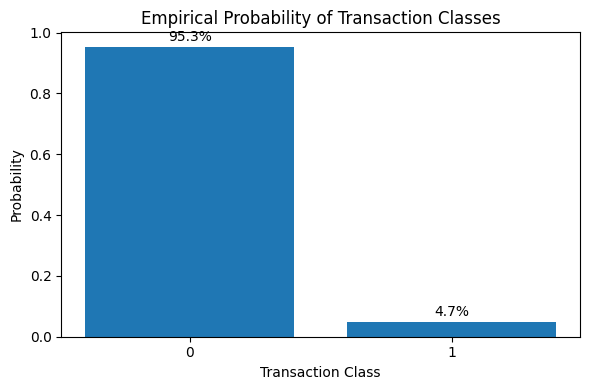

0.0
count    2.098730e+05
mean     1.026502e+04
std      9.364579e+04
min      5.450000e+00
25%      2.164500e+03
50%      6.091220e+03
75%      1.045151e+04
max      1.261850e+07
Name: Amount, dtype: float64
count    2.098730e+05
mean     1.026502e+04
std      9.364579e+04
min      5.450000e+00
50%      6.091220e+03
90%      1.667048e+04
95%      2.241625e+04
99%      4.943524e+04
99.9%    4.772012e+05
max      1.261850e+07
Name: Amount, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


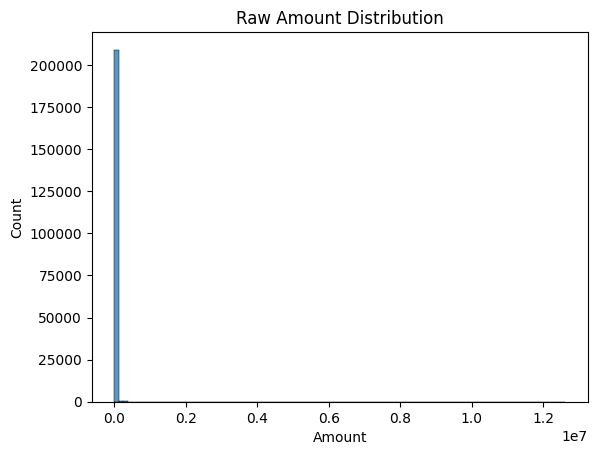

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


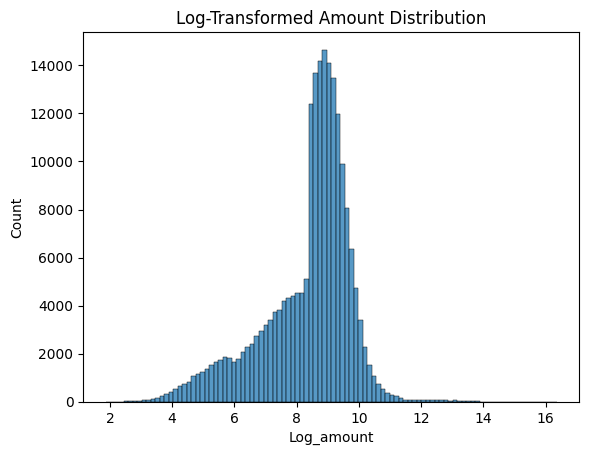

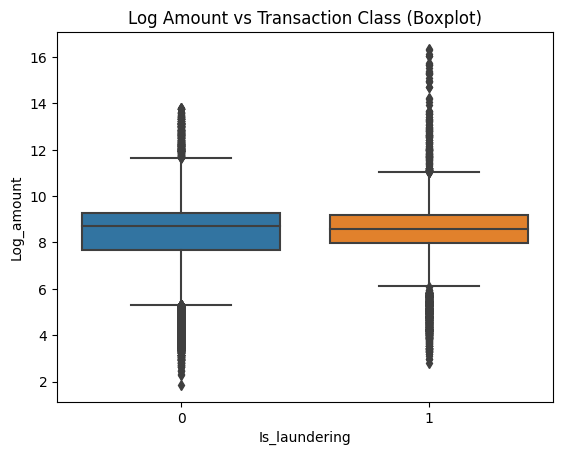

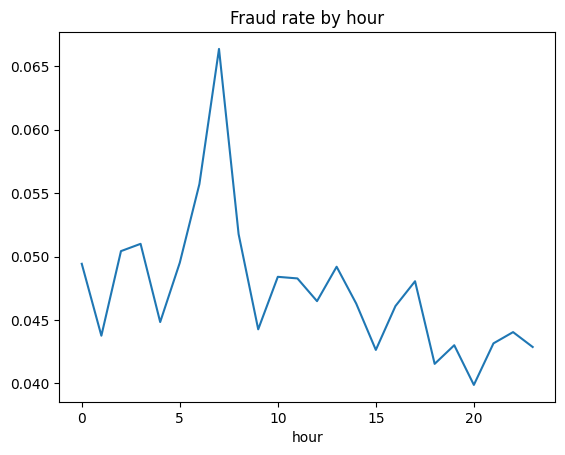

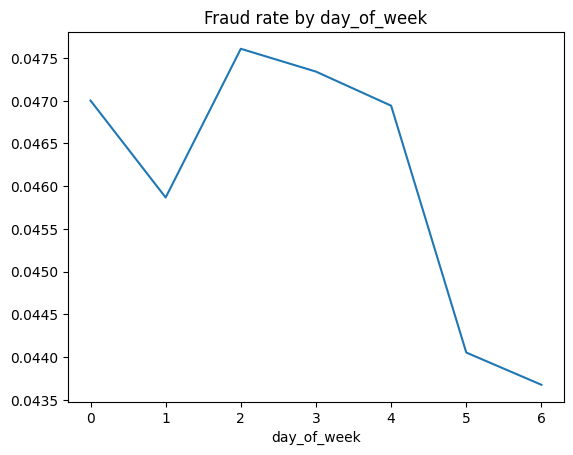

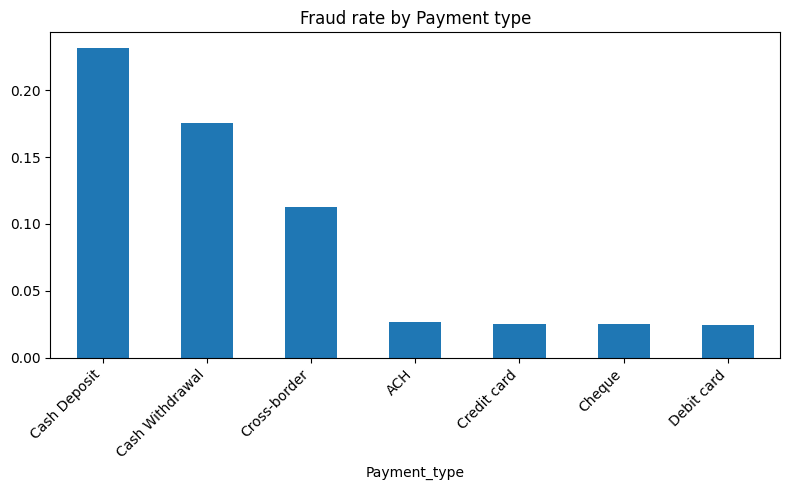

len(feature_names): 69
first few feature names: ['Payment_currency_Albanian lek' 'Payment_currency_Dirham'
 'Payment_currency_Euro' 'Payment_currency_Indian rupee'
 'Payment_currency_Mexican Peso' 'Payment_currency_Moroccan dirham'
 'Payment_currency_Naira' 'Payment_currency_Pakistani rupee'
 'Payment_currency_Swiss franc' 'Payment_currency_Turkish lira']
len(feature_names): 69
first few feature names: ['Payment_currency_Albanian lek' 'Payment_currency_Dirham'
 'Payment_currency_Euro' 'Payment_currency_Indian rupee'
 'Payment_currency_Mexican Peso' 'Payment_currency_Moroccan dirham'
 'Payment_currency_Naira' 'Payment_currency_Pakistani rupee'
 'Payment_currency_Swiss franc' 'Payment_currency_Turkish lira']

EXPERIMENT: baseline_only
Number of features:  78
Paired t-test p-value: 7.618372874045571e-05
Boostrap CI for  [-0.11540407 -0.09412833]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.24459234608985025
Test recall 0.20655737704918034
Precision

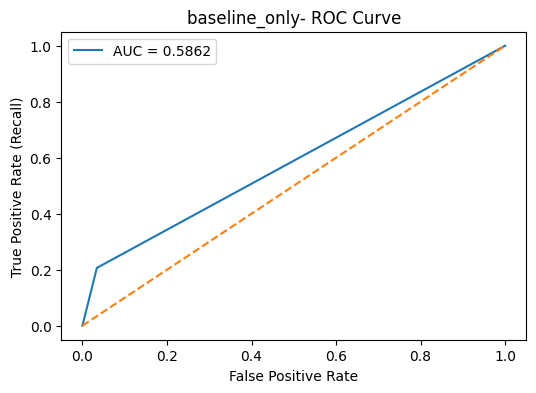

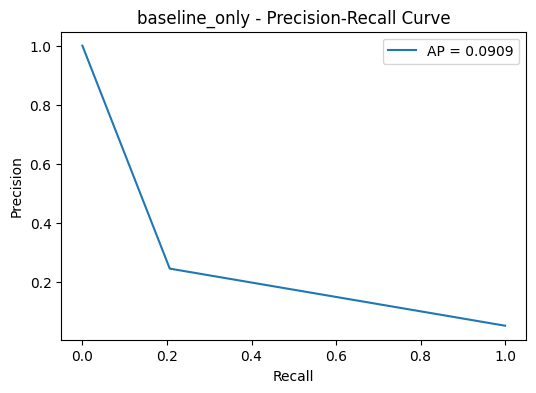


EXPERIMENT: new_pattern_only
Number of features:  4
Paired t-test p-value: 0.10167760677085716
Boostrap CI for  [-0.00435307 -0.00044928]
Best threshold: 0.778784613654487
Validation probability quantiles: [0.77878461 0.77878461 0.79164866 0.79164866]
Test precision: 0.16016483516483518
Test recall 0.546135831381733
Precision CI [0.15163605 0.16875006]
Recall CL [0.52493048 0.5668734 ]


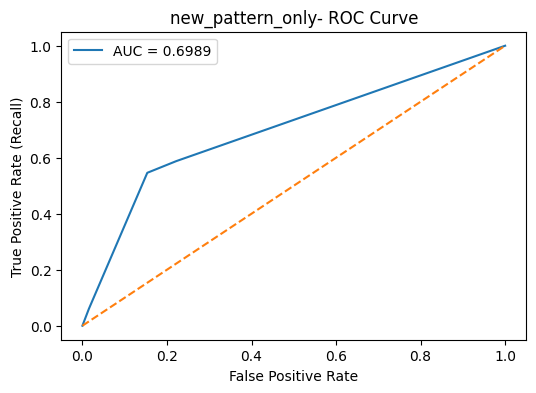

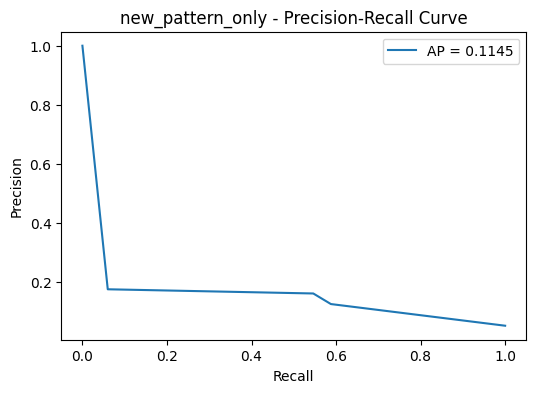


EXPERIMENT: burst_only
Number of features:  3
Paired t-test p-value: 0.08173312190727303
Boostrap CI for  [-9.46141022e-09 -1.26136439e-09]
Best threshold: 0.5
Validation probability quantiles: [0.51165589 0.51165589 0.51165589 0.51165589]
Test precision: 0.053882678206515204
Test recall 0.8398126463700234
Precision CI [0.05134739 0.05630103]
Recall CL [0.8233314  0.85599012]


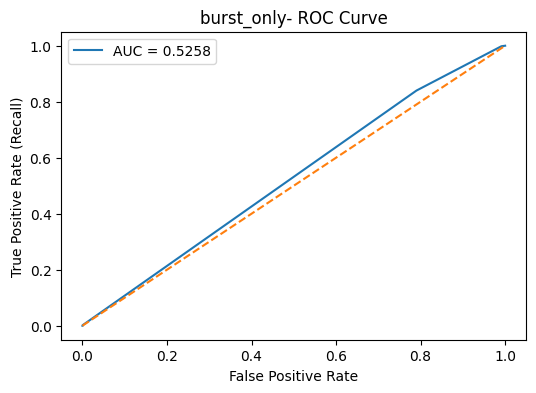

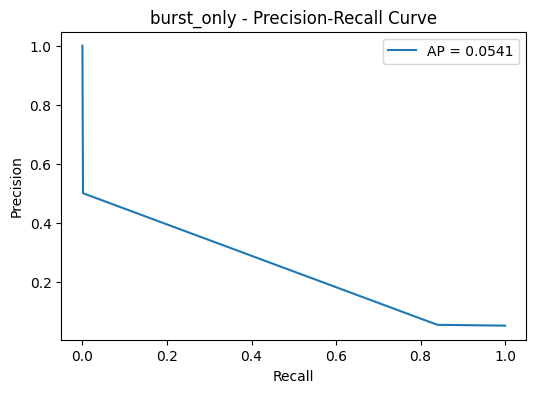


EXPERIMENT: temporal_only
Number of features:  8
Paired t-test p-value: 5.1955757989196766e-05
Boostrap CI for  [-0.04663594 -0.03820114]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.17434210526315788
Test recall 0.14894613583138172
Precision CI [0.15769218 0.19139227]
Recall CL [0.13421212 0.16446628]


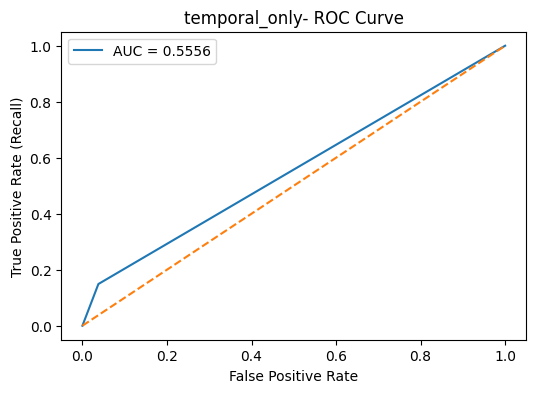

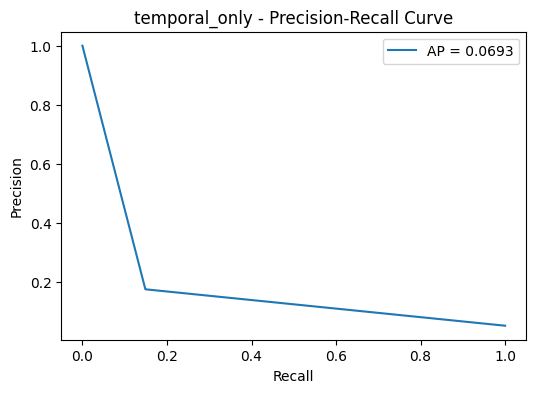


EXPERIMENT: sender_profile_only
Number of features:  4
Paired t-test p-value: nan
Boostrap CI for  [0. 0.]
Best threshold: 0.8217118244268395
Validation probability quantiles: [0.42335425 0.42335425 0.94838368 0.98805439]
Test precision: 0.28733264675592174
Test recall 0.1306791569086651
Precision CI [0.26076518 0.31643594]
Recall CL [0.11745207 0.14589011]


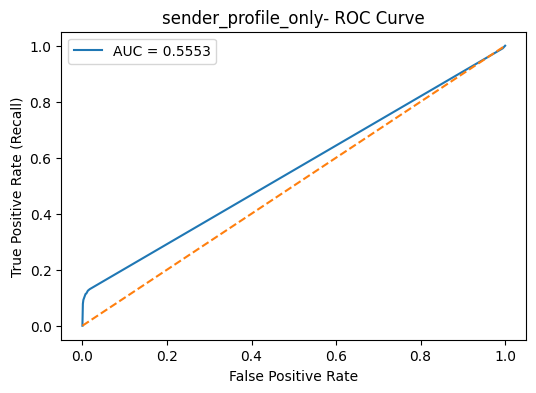

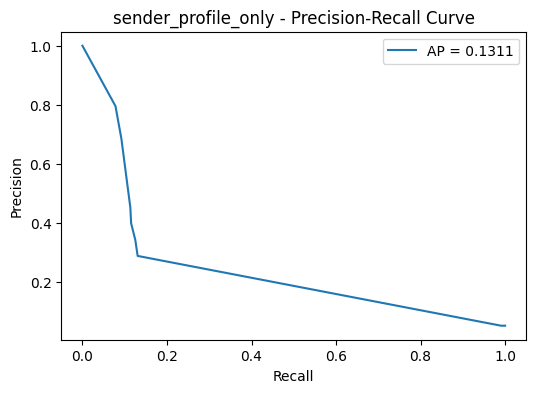


EXPERIMENT: baseline_plus_new_pattern
Number of features:  82
Paired t-test p-value: 0.00016587283711526357
Boostrap CI for  [-0.08875789 -0.06905486]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.234375
Test recall 0.20374707259953162
Precision CI [0.21497782 0.25293841]
Recall CL [0.18513021 0.22165707]


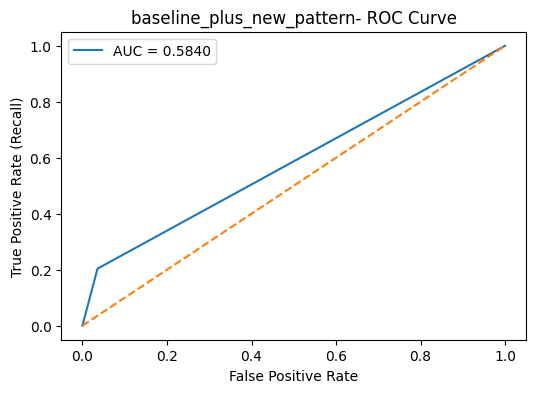

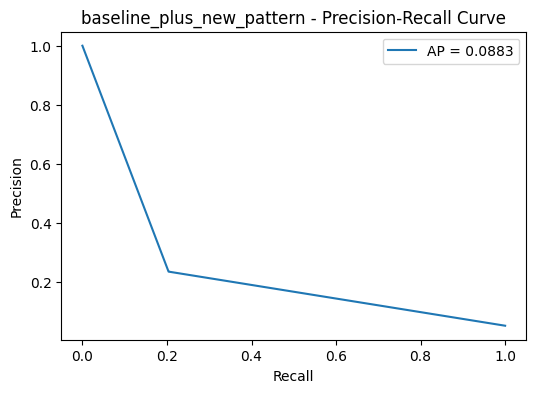


EXPERIMENT: baseline_plus_temporal
Number of features:  86
Paired t-test p-value: 0.0002975001273735085
Boostrap CI for  [-0.06465941 -0.04863745]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.3446054750402576
Test recall 0.3007025761124122
Precision CI [0.3231708  0.36567673]
Recall CL [0.28227824 0.31831222]


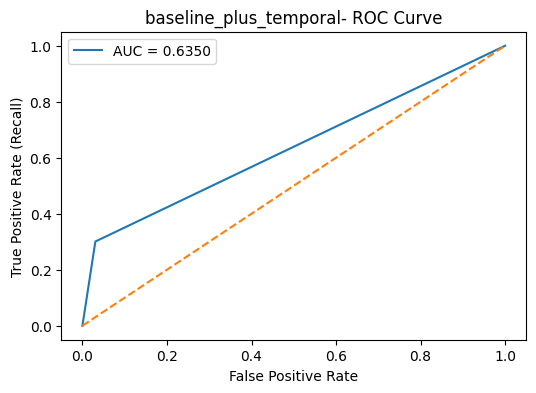

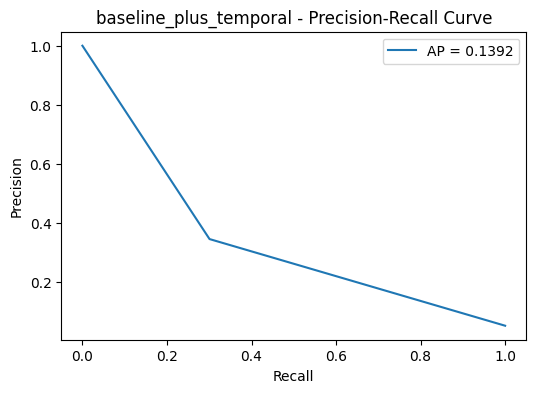


EXPERIMENT: baseline_plus_sender_profile
Number of features:  82
Paired t-test p-value: 0.6045757957168143
Boostrap CI for  [-0.01497656  0.04324365]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.2568286626463285
Test recall 0.33911007025761125
Precision CI [0.24117748 0.27391595]
Recall CL [0.32074576 0.35918874]


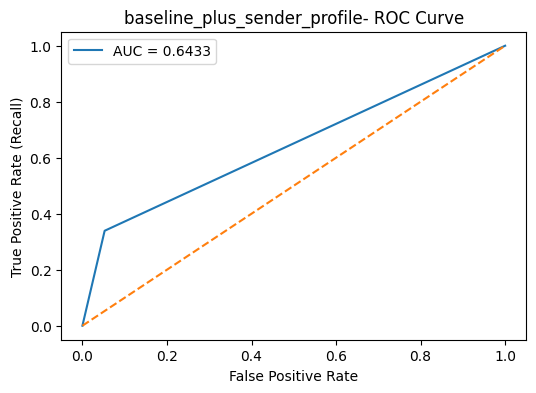

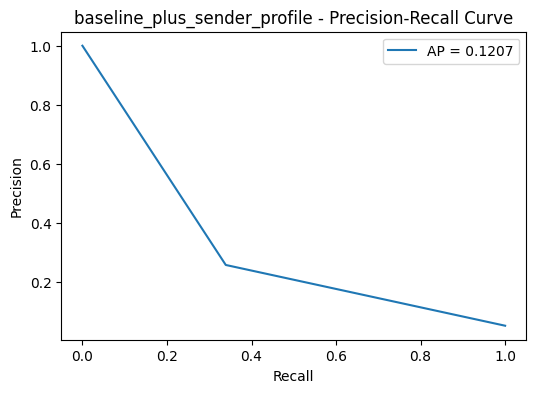


EXPERIMENT: baseline_plus_new_plus_temporal
Number of features:  90
Paired t-test p-value: 0.9673984890976319
Boostrap CI for  [-0.00627444  0.00709441]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.3359662980516061
Test recall 0.29882903981264636
Precision CI [0.31459948 0.35663728]
Recall CL [0.2797244  0.31898718]


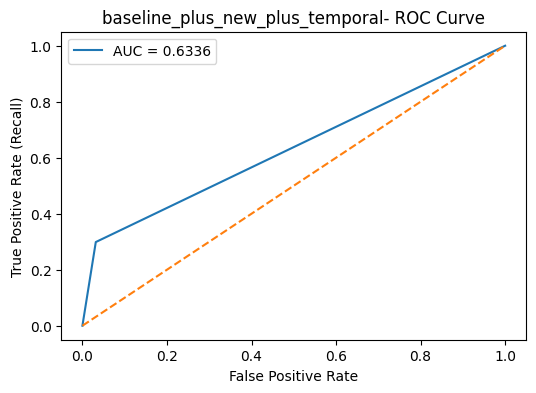

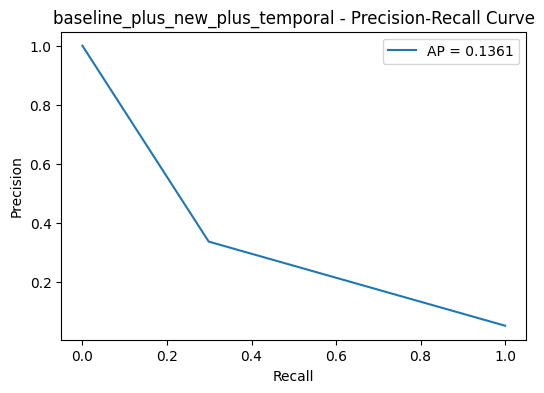


EXPERIMENT: full_features
Number of features:  97
Paired t-test p-value: 0.17091985509778257
Boostrap CI for  [-0.00031124  0.00926124]
Best threshold: 1.0
Validation probability quantiles: [0. 0. 1. 1.]
Test precision: 0.34004914004914005
Test recall 0.32412177985948476
Precision CI [0.32090285 0.36172221]
Recall CL [0.3055931  0.34302285]


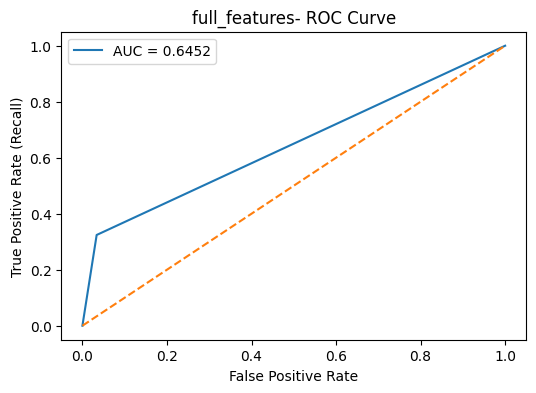

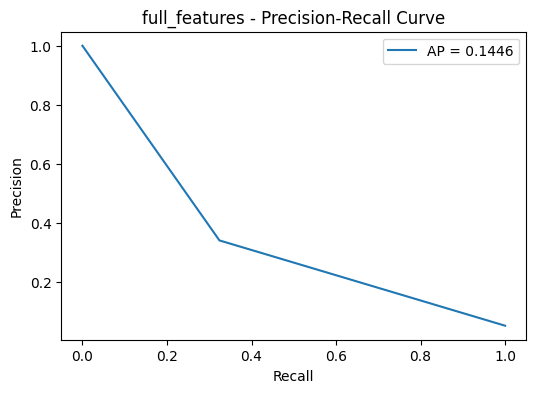


ABLATION RESULTS
                        experiment  n_features  best_threshold   p_value  \
6           baseline_plus_temporal          86        1.000000  0.000298   
9                    full_features          97        1.000000  0.170920   
8  baseline_plus_new_plus_temporal          90        1.000000  0.967398   
4              sender_profile_only           4        0.821712       NaN   
7     baseline_plus_sender_profile          82        1.000000  0.604576   
0                    baseline_only          78        1.000000  0.000076   
5        baseline_plus_new_pattern          82        1.000000  0.000166   
3                    temporal_only           8        1.000000  0.000052   
1                 new_pattern_only           4        0.778785  0.101678   
2                       burst_only           3        0.500000  0.081733   

   cv_diff_ci_low  cv_diff_ci_high  test_precision  test_recall  \
6   -6.465941e-02    -4.863745e-02        0.344605     0.300703   
9   -3.1123

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [12]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
from sklearn.metrics import (
        roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)


def save_artifacts(
    artifact_dir,
    model,
    encoder,
    threshold,
    features,
    cat_cols,
    risky_artifacts,
    senderbehaviour
):
    os.makedirs(artifact_dir, exist_ok=True)

    joblib.dump(model, os.path.join(artifact_dir, "model.pkl"))
    joblib.dump(encoder, os.path.join(artifact_dir, "encoder.pkl"))
    joblib.dump(senderbehaviour, os.path.join(artifact_dir, "senderbehaviour.pkl"))

    with open(os.path.join(artifact_dir, "threshold.json"), "w") as f:
        json.dump({"threshold": float(threshold)}, f)

    with open(os.path.join(artifact_dir, "features.json"), "w") as f:
        json.dump({
            "feature_columns": features,
            "categorical_columns": cat_cols
        }, f, indent=2)

    risky_serializable = {}
    for col, info in risky_artifacts.items():
        risky_serializable[col] = {
            "risky_pairs": [(str(v), int(dec)) for v, dec in info["risky_pairs"]],
            "bin_edges": [float(x) for x in info["bin_edges"]]
        }

    with open(os.path.join(artifact_dir, "risky_flags.json"), "w") as f:
        json.dump(risky_serializable, f, indent=2)


def main():
    
    # 1. LOAD DATA
    
    path = "/kaggle/input/synthetic-transaction-monitoring-dataset-aml/SAML-D.csv"
    df = pd.read_csv(path).copy()
    fraud = df[df["Is_laundering"] == 1]
    normal = df[df["Is_laundering"] == 0].sample(
    200_000,
    random_state=42)

    df = pd.concat([fraud, normal]).sample(
    frac=1,
    random_state=42).copy()

    
    # 2. BASIC OVERVIEW / EDA
    
    overviewer = DataOverviewer()
    overviewer.datasetOverview(df)

    explorer = AMLExplorer(df)
    explorer.plot_class_distribution()
    df = explorer.eda_amount()

    # 3. TIME SPLIT
    
    splitter = DataFrame_Split()
    train_df, test_df = splitter.train_test_split(df)

    
    # 4. BASIC FEATURES
    
    basic_eng = BasicFeatureEngineering()
    train_df, test_df = basic_eng.new_features(train_df, test_df)

    # 5. RISKY FLAGS
    
    risky_cols = ["Payment_type", "Receiver_bank_location"]
    risky_artifacts = {}

    for col in risky_cols:
        risky_pairs, bin_edges = basic_eng.fit_risky_flags(train_df, col)
        risky_artifacts[col] = {
            "risky_pairs": risky_pairs,
            "bin_edges": bin_edges
        }

        train_df = basic_eng.transform_risky_feature(train_df, col, risky_pairs, bin_edges)
        test_df = basic_eng.transform_risky_feature(test_df, col, risky_pairs, bin_edges)

    # 6. SENDER BEHAVIOUR 
    
    sender_feat = SenderBehaviourFeatures()
    senderbehaviour = sender_feat.sendergrouping_eng(train_df)

    train_df = sender_feat.merging(senderbehaviour, train_df)
    test_df = sender_feat.merging(senderbehaviour, test_df)

    # 7. BURST FEATURES
    
    time_feat = TimeFeatures()
    train_df, test_df = time_feat.burst_transactions(train_df, test_df)

    # fill NaN burst values if needed
    burst_cols = [
        "burst_small_payments_every10min",
        "all_payments_every_10min",
        "Small_payments_Percentage_every"
    ]
    for col in burst_cols:
        train_df[col] = train_df[col].fillna(0)
        test_df[col] = test_df[col].fillna(0)

    # 8. NEW TEMPORAL FEATURES
    train_df = sender_feat.add_rolling_amount_features(train_df)
    test_df = sender_feat.add_rolling_amount_features(test_df)

    train_df = sender_feat.add_tx_count_features(train_df)
    test_df = sender_feat.add_tx_count_features(test_df)

    train_df = sender_feat.add_unique_receivers_features(train_df)
    test_df = sender_feat.add_unique_receivers_features(test_df)

    train_df = sender_feat.add_amount_ratio_feature(train_df)
    test_df = sender_feat.add_amount_ratio_feature(test_df)

    #NEW ADDED FEATURES BASED ON EDA DIAGRAMS

    risk_pattern = RiskPatternFeatures()
    train_df = risk_pattern.new_features(train_df)
    test_df = risk_pattern.new_features(test_df)
    
    # 9. OPTIONAL BASIC FEATURE EDA
    
    feature_eda = BasicFeatureEDA()
    feature_eda.eda(train_df)
    
    # 10. ENCODING
    
    cat_cols = [
        "Payment_currency",
        "Received_currency",
        "Sender_bank_location",
        "Receiver_bank_location",
        "Payment_type"
    ]

    encoder = Encoder(cat_cols)
    encoder.fit(train_df)

    train_encoded = encoder.transform(train_df)
    test_encoded = encoder.transform(test_df)

    # 11. FEATURES / TARGET

    target = "Is_laundering"

    drop_cols = [
        target,
        "Date",
        "Time",
        "timestamp",
        "Sender_account",
        "Receiver_account", 
        "Laundering_type"
    ]

    feature_cols = [col for col in train_encoded.columns if col not in drop_cols]

    # We only keep the features that are both in X_train, X_test
    common_features = [c for c in feature_cols if c in test_encoded.columns]

    # 12. DEFINE FEATURE GROUPS
    temporal_features = [
    c for c in [
        "sum_amount_last_1hr",
        "sum_amount_last_24hr",
        "tx_count_last_1hr",
        "tx_count_last_24hr",
        "unique_receivers_last_1hr",
        "unique_receivers_last_24hr",
        "sender_hist_mean_amount",
        "amount_to_sender_mean_ratio",
    ]
    if c in common_features
]
    new_pattern_features = [
        c for c in [
        "high_risk_hour",
        "high_risk_day",
        "high_risk_payment_type",
        "combined_risk_flag",
        "risk_pattern_score",
        ] 
         if c in common_features
    ]
    
    sender_profile_features = [
        c for c in [
            "sender_transaction_count",
            "sender_mean_Amount",
            "sender_std_Amount",
            "receiver_bank_loc_n",
        ]
        if c in common_features
    ]
    
    # burst features = ξεχωριστή κατηγορία temporal-like features
    burst_features = [
        c for c in [
            "burst_small_payments_every10min",
            "all_payments_every_10min",
            "Small_payments_Percentage_every",
        ]
        if c in common_features
    ]
    
    # TRUE baseline = basic + OHE + risky flags
    # Δηλαδή αφαιρούμε temporal, sender profile, burst
    exclude_from_baseline = (
        temporal_features
        + sender_profile_features
        + burst_features
        + new_pattern_features
    )

    baseline_features = [
        c for c in common_features
        if c not in exclude_from_baseline
    ]
    
    full_features = list(dict.fromkeys(
        baseline_features
        + burst_features
        + temporal_features
        + sender_profile_features
    ))

    experiments = {
        "baseline_only": baseline_features,
    
        "new_pattern_only": new_pattern_features,
        "burst_only": burst_features,
        "temporal_only": temporal_features,
        "sender_profile_only": sender_profile_features,
    
        "baseline_plus_new_pattern": baseline_features + new_pattern_features,
        "baseline_plus_temporal": baseline_features + temporal_features,
        "baseline_plus_sender_profile": baseline_features + sender_profile_features,
    
        "baseline_plus_new_plus_temporal": (
            baseline_features + new_pattern_features + temporal_features
        ),
           
        "full_features": (
            baseline_features
            + new_pattern_features
            + burst_features
            + temporal_features
            + sender_profile_features
        )
    }
    # 13. RUN ABLATION
    # =========================
    results = []

    for exp_name, feature_list in experiments.items():
        # remove duplicates while preserving order
        feature_list = list(dict.fromkeys(feature_list))

        result = run_one_experiment(
            train_encoded=train_encoded,
            test_encoded=test_encoded,
            feature_list=feature_list,
            target=target,
            exp_name=exp_name
        )
        results.append(result)

    # =========================
    # 14. RESULTS TABLE
    # =========================
    results_df = pd.DataFrame(results)

    display_cols = [
        c for c in results_df.columns
        if c not in ["model", "features"]
    ]
    results_df_display = results_df[display_cols].sort_values(
        by=["test_precision", "test_recall"],
        ascending=False
    )

    print("\n" + "=" * 60)
    print("ABLATION RESULTS")
    print("=" * 60)
    print(results_df_display)

    #SELECT Best EXPERIMENT FOR PRODUCTION

    best_exp_name = "full_features"

    best_result = None
    for r in results:
        if r["experiment"] == best_exp_name:
            best_result = r
            break
            
    if best_result is None:
        raise ValueError(f"Experiment {best_exp_name} not found")

    
    #16. SAVE ARTIFACTS
    
    save_artifacts(
        artifact_dir = "/kaggle/working/artifacts",
        model=best_result["model"],
        encoder=encoder,
        threshold=best_result["threshold"],
        features=best_result["features"],
        cat_cols=cat_cols,
        risky_artifacts=risky_artifacts,
        senderbehaviour=senderbehaviour
    )

    print("\nArtifacts saved in ../artifacts")
 

if __name__ == "__main__":
    main()
